In [2]:
import pandas as pd
import statsmodels
import requests
import seaborn as sns
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import ccf
import numpy as np
import os
from scipy import stats

### Fetch data with API

In [ ]:
LAT, LON = 56.1629, 10.2039  # Aarhus
START, END = "2025-04-18", "2026-04-18"

# ── 1. Historical air quality (NO2, O3) ──────────────────────────────────────
print("Fetching air quality...")
aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "nitrogen_dioxide,ozone,pm10,pm2_5",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

aq_df = pd.DataFrame({
    "Recorded": pd.to_datetime(aq["hourly"]["time"]),
    "NO2":      aq["hourly"]["nitrogen_dioxide"],
    "O3":       aq["hourly"]["ozone"],
    "PM10":     aq["hourly"]["pm10"],
    "PM2.5":    aq["hourly"]["pm2_5"],
})

# ── 2. Historical weather (wind, temp, radiation) ──────────────────────
print("Fetching weather...")
wx = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "wind_speed_10m,wind_direction_10m,temperature_2m,shortwave_radiation,relative_humidity_2m",
        "wind_speed_unit": "ms",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

wx_df = pd.DataFrame({
    "Recorded":           pd.to_datetime(wx["hourly"]["time"]),
    "wind_speed":         wx["hourly"]["wind_speed_10m"],
    "temperature":        wx["hourly"]["temperature_2m"],
    "solar_radiation":    wx["hourly"]["shortwave_radiation"],
    "humidity":           wx["hourly"]["relative_humidity_2m"],

})

# ── 3. Merge and save ─────────────────────────────────────────────────────────
print("Merging...")
df = aq_df.merge(wx_df, on="Recorded", how="inner")
df = df.sort_values("Recorded").reset_index(drop=True)

print(f"\nFinal shape: {df.shape}")
print(df.head())
print(f"\nDate range: {df.Recorded.min()} → {df.Recorded.max()}")
print(f"Missing values:\n{df.isnull().sum()}")

Fetching air quality...
Fetching weather...
Merging...

Final shape: (8784, 9)
             Recorded  NO2    O3  PM10  PM2.5  wind_speed  temperature  \
0 2025-04-18 00:00:00  3.4  90.0   3.8    2.9        4.52          8.3   
1 2025-04-18 01:00:00  3.1  91.0   3.2    2.6        4.51          7.9   
2 2025-04-18 02:00:00  2.5  95.0   3.0    2.1        4.40          7.8   
3 2025-04-18 03:00:00  2.7  92.0   3.1    2.0        4.44          7.8   
4 2025-04-18 04:00:00  2.6  87.0   3.4    2.6        4.70          7.8   

   solar_radiation  humidity  
0              0.0        86  
1              0.0        87  
2              0.0        86  
3              0.0        91  
4              0.0        89  

Date range: 2025-04-18 00:00:00 → 2026-04-18 23:00:00
Missing values:
Recorded           0
NO2                0
O3                 0
PM10               0
PM2.5              0
wind_speed         0
temperature        0
solar_radiation    0
humidity           0
dtype: int64


### Examine correlations matrix for exogenous variables

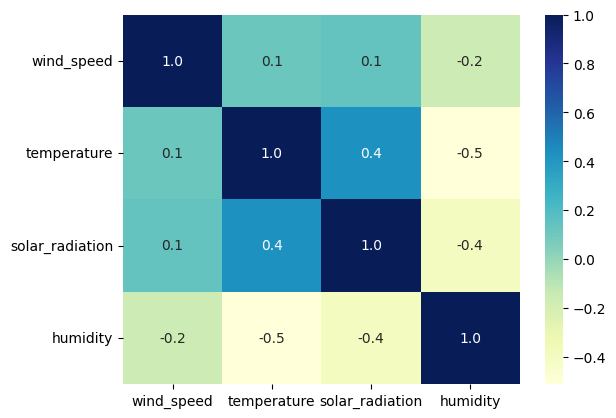

In [5]:
def difference_exog(df, exog_cols, m):
    df_diff = df[exog_cols].copy()
    
    for col in exog_cols:
        df_diff[col] = df[col] - df[col].shift(m)        # seasonal diff
        df_diff[col] = df_diff[col] - df_diff[col].shift(1)  # first diff on top
    
    return df_diff.dropna()

exg_columns = ['wind_speed', 'temperature', 'solar_radiation', 'humidity']
df_diff = difference_exog(df, exg_columns, m=24)

co_mtx = df_diff.corr()
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt=".1f")
plt.show()

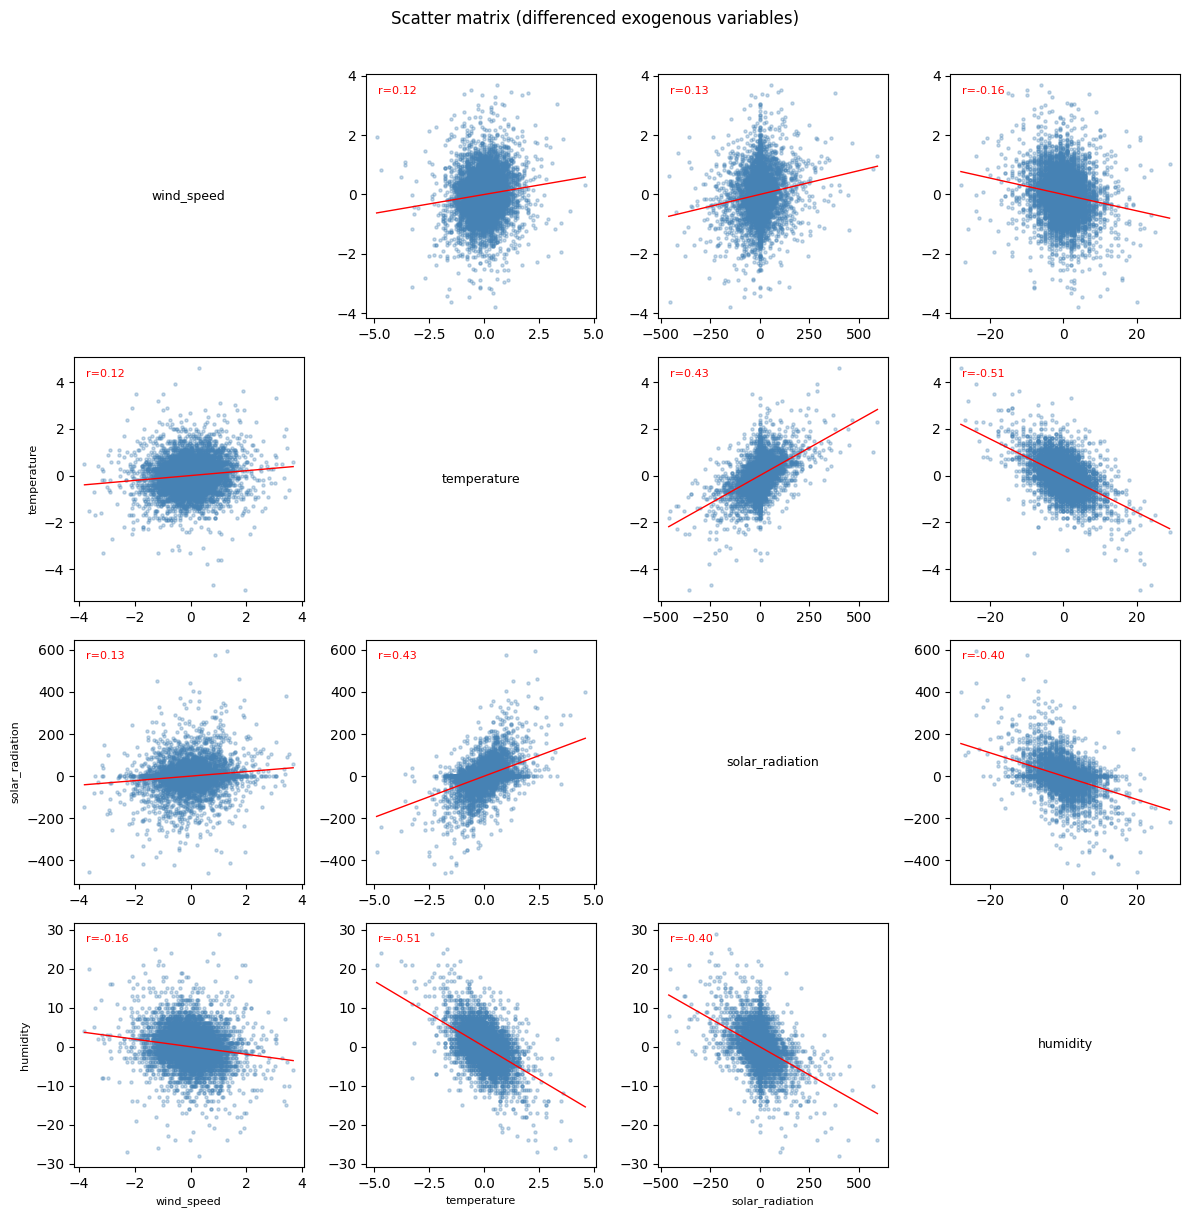

In [6]:
def plot_scatter_matrix(df_diff, exog_cols, save_path):

    """
    Plot a scatter matrix with all exogenous variables and save to file
    """
    n = len(exog_cols)
    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))

    for i, col_i in enumerate(exog_cols):
        for j, col_j in enumerate(exog_cols):
            ax = axes[i, j]

            if i == j:
                ax.text(0.5, 0.5, col_i, transform=ax.transAxes,
                        ha='center', va='center', fontsize=9)
                ax.set_axis_off()
                continue

            x = df_diff[col_j].values
            y = df_diff[col_i].values

            ax.scatter(x, y, alpha=0.3, s=5, color='steelblue')

            slope, intercept, r, _, _ = stats.linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1)

            ax.text(0.05, 0.92, f'r={r:.2f}', transform=ax.transAxes,
                    fontsize=8, color='red')

            if i == n - 1:
                ax.set_xlabel(col_j, fontsize=8)
            if j == 0:
                ax.set_ylabel(col_i, fontsize=8)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.suptitle('Scatter matrix (differenced exogenous variables)', y=1.01)
    plt.tight_layout()
    plt.show()

plot_scatter_matrix(df_diff, exg_columns, save_path = os.path.join('..', 'out', 'plots', 'corr_exg_variables.png'))